# Spreadsheet to FAIRFluids Tutorial (CSV + XLSX)

This notebook shows the current recommended workflow for importing structured tabular data into FAIRFluids using `FluidIO`.

What is covered:
- Generate a parser-compatible template (`csv` or `xlsx`)
- Fill data in spreadsheet format (multiple properties per row)
- Import with global units at read-time
- Optional PubChem enrichment using `pubchemID i`
- Validate created documents/fluids/measurements


## 1) Imports and setup


In [1]:
from pathlib import Path

from fairfluids.core.fluid_io import FluidIO

fio = FluidIO()

print("Parsable properties:", fio.get_parsable_property_keywords())
print("Parsable parameters:", fio.get_parsable_parameter_keywords())

workflows_dir = Path("/home/sga/Code/FAIRFluids/Workflows")
workflows_dir.mkdir(parents=True, exist_ok=True)

Parsable properties: {'viscosity': 'VISCOSITY', 'density': 'DENSITY', 'conductivity': 'ELECTRICAL_CONDUCTIVITY', 'electrical_conductivity': 'ELECTRICAL_CONDUCTIVITY', 'thermal_conductivity': 'THERMAL_CONDUCTIVITY'}
Parsable parameters: {'temperature': 'TEMPERATURE', 'pressure': 'PRESSURE', 'mole_fraction': 'MOLE_FRACTION', 'molar_fraction': 'MOLE_FRACTION', 'time': 'TIME'}


## 2) Create a structured template (XLSX or CSV)


In [2]:
template_xlsx = workflows_dir / "test.xlsx"

aio = fio.create_datasheet(
    output_path=str(template_xlsx),
    file_format="xlsx",              # or "csv"
    properties=["viscosity", "density", "conductivity"],
    n_compounds=3,
    parameters=["time"],             # optional extra parameters
    n_rows=30,
)

print("Template written:", aio)
print("Fill the spreadsheet, then run the import cell below.")

Template written: /home/sga/Code/FAIRFluids/Workflows/test.xlsx
Fill the spreadsheet, then run the import cell below.


In [3]:
# Use a filled spreadsheet path here
spreadsheet_path = workflows_dir / "filled.xlsx"  # or workflows_dir / "test.csv"

# Units can be supplied globally at read-time (unit columns in sheet are optional)
units = {
    "temperature": "K",
    "pressure": "bar",         # optional in data rows
    "viscosity": "cP",
    "density": "g/cm3",
    "conductivity": "mS/cm",
}
uncertainty_units = {
    "temperature": "K",
    "pressure": "bar",
    "viscosity": "cP",
    "density": "g/cm3",
    "conductivity": "mS/cm",
}

# Use data_from_spreadsheet (csv/xlsx) or data_from_csv (backward-compatible wrapper)
docs = fio.data_from_spreadsheet(
    spreadsheet_path=str(spreadsheet_path),
    fetch_from_pubchem=True,
    units=units,
    uncertainty_units=uncertainty_units,
)

print(f"Documents: {len(docs)}")
print(f"Fluids in first document: {len(docs[0].fluid) if docs else 0}")

Found 1 unique compound combinations

Fetching compound information from PubChem for 3 unique compounds...

Fetched data for 3 compounds

  Added compound: water -> Water (CID: 962)
  Added compound: Cholinechloride -> Choline Chloride (CID: 6209)
  Added compound: Glycerol -> Glycerol (CID: 753)
Documents: 1
Fluids in first document: 6


In [4]:
import json
from fairfluids.core.lib import FAIRFluidsDocument

with open("/home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet/water_Cholinechloride_Glycerol.json", "r") as f:
    data = json.load(f)
docs = FAIRFluidsDocument.model_validate(data)

docs

FAIRFluidsDocument(version=Version(versionMajor=1, versionMinor=0), citation=None, compound=[Compound(compoundID='Water', pubChemID=962, commonName='Water', SELFIE=None, name_IUPAC='oxidane', standard_InChI='InChI=1S/H2O/h1H2', standard_InChI_key='XLYOFNOQVPJJNP-UHFFFAOYSA-N', molar_weigth=18.015, smiles_code='O', sigma_profile=None), Compound(compoundID='Choline Chloride', pubChemID=6209, commonName='Choline Chloride', SELFIE=None, name_IUPAC='2-hydroxyethyl(trimethyl)azanium chloride', standard_InChI='InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1', standard_InChI_key='SGMZJAMFUVOLNK-UHFFFAOYSA-M', molar_weigth=139.62, smiles_code='C[N+](C)(C)CCO.[Cl-]', sigma_profile=None), Compound(compoundID='Glycerol', pubChemID=753, commonName='Glycerol', SELFIE=None, name_IUPAC='propane-1,2,3-triol', standard_InChI='InChI=1S/C3H8O3/c4-1-3(6)2-5/h3-6H,1-2H2', standard_InChI_key='PEDCQBHIVMGVHV-UHFFFAOYSA-N', molar_weigth=92.09, smiles_code='C(C(CO)O)O', sigma_profile=None)], fl

In [5]:
from fairfluids.operations import calculate_ratio_of_solvent
docs = calculate_ratio_of_solvent(
    doc=docs,
    name="glyceline",
    compound_id_1="Glycerol",
    compound_id_2="Choline Chloride",
    precision=0,
    print_reported_value=True,
)

print(docs.model_dump_json(indent=2))

=== Calculating Solvent Ratio: glyceline ===
Processing 6 fluids

--- Processing Fluid 1 ---
Measurement meas_780c8194-dbc4-42a8-9b8c-e99e36922101: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_74c050af-0663-4e75-bf57-0e325269a646: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_ebd7699d-cf33-4152-8a57-886cb1fe5fe8: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_3707b79e-0f25-4c54-b246-207ac93c395b: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_f92f8b54-8bbb-4e57-aaf5-3fdd8788f4bf: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_01868538-2967-4aad-a8e5-180a97f1578f: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_4610b77a-b732-4af0-9a27-1a2f45ee4126: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_a3d733b0-bbab-4186-bfb7-4dcb97cd9a3c: reported ratio = 2.0, calculated ratio = 2.0
Measurement meas_f4a5904c-e55c-4712-8749-4be6219ee581: reported ratio = 2.0, calculated ratio = 2.0
Measure

In [6]:
with open("/home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet/water_Cholinechloride_Glycerol.json", "w") as f:
    f.write(docs.model_dump_json(indent=2))


In [7]:
import pandas as pd

# Unpack one Fluid into a flat DataFrame using schema enums from the document
def fluid_to_dataframe(fluid) -> pd.DataFrame:
    # Resolve IDs to fixed enum values from the document schema
    prop_enum_by_id = {
        p.propertyID: (p.properties.value if p.properties is not None else p.propertyID)
        for p in fluid.property
    }
    param_enum_by_id = {
        p.parameterID: (p.parameters.value if p.parameters is not None else p.parameterID)
        for p in fluid.parameter
    }

    rows = []
    for meas in fluid.sample.measurement:
        row = {
            "measurement_id": meas.measurement_id,
            "source_doi": meas.source_doi,
            "method": meas.method.value if meas.method else None,
        }
        for pv in meas.propertyValue:
            prop_key = prop_enum_by_id.get(pv.propertyID, pv.propertyID)
            row[f"prop_{prop_key}"] = pv.propValue
            if pv.uncertainty is not None:
                row[f"prop_{prop_key}_unc"] = pv.uncertainty
        for par in meas.parameterValue:
            par_key = param_enum_by_id.get(par.parameterID, par.parameterID)
            row[f"param_{par_key}"] = par.paramValue
        rows.append(row)
    return pd.DataFrame(rows)


# docs is a FAIRFluidsDocument from model_validate(...)
fluid0 = docs.fluid[0]
print(f"Fluid compounds: {fluid0.compounds}")
df0 = fluid_to_dataframe(fluid0)
df0.head(10)


Fluid compounds: ['Water', 'Choline Chloride', 'Glycerol']


,measurement_id,source_doi,method,prop_viscosity,param_Temperature,param_Mole fraction,param_Solvent: Amount ratio of component to other component of binary solvent
0,meas_780c8194-dbc4-42a8-9b8c-e99e36922101,10.1016/j.molliq.2021.117463,measured,0.39722,294.13,0.653333,2.0
1,meas_74c050af-0663-4e75-bf57-0e325269a646,10.1016/j.molliq.2021.117463,measured,0.37388,295.17,0.653333,2.0
2,meas_ebd7699d-cf33-4152-8a57-886cb1fe5fe8,10.1016/j.molliq.2021.117463,measured,0.34970,296.18,0.653333,2.0
3,meas_3707b79e-0f25-4c54-b246-207ac93c395b,10.1016/j.molliq.2021.117463,measured,0.32707,297.19,0.653333,2.0
4,meas_f92f8b54-8bbb-4e57-aaf5-3fdd8788f4bf,10.1016/j.molliq.2021.117463,measured,0.30615,298.20,0.653333,2.0
5,meas_01868538-2967-4aad-a8e5-180a97f1578f,10.1016/j.molliq.2021.117463,measured,0.28607,299.20,0.653333,2.0
6,meas_4610b77a-b732-4af0-9a27-1a2f45ee4126,10.1016/j.molliq.2021.117463,measured,0.26815,300.20,0.653333,2.0
7,meas_a3d733b0-bbab-4186-bfb7-4dcb97cd9a3c,10.1016/j.molliq.2021.117463,measured,0.25095,301.20,0.653333,2.0
8,meas_f4a5904c-e55c-4712-8749-4be6219ee581,10.1016/j.molliq.2021.117463,measured,0.23531,302.20,0.653333,2.0
9,meas_b201c7ef-efe9-4494-a63b-1f147210dcf4,10.1016/j.molliq.2021.117463,measured,0.22096,303.20,0.653333,2.0


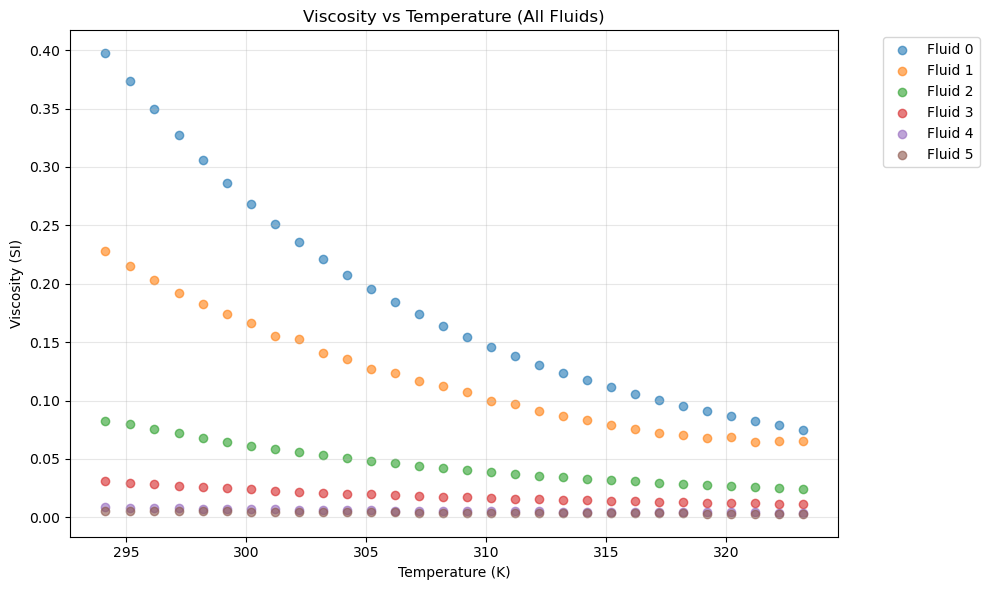

In [8]:

from fairfluids.core.lib import Properties, Parameters
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Match enum-based column names from fluid_to_dataframe
viscosity_col = f"prop_{Properties.VISCOSITY.value}"
temp_col = f"param_{Parameters.TEMPERATURE.value}"

plotted_any = False
for i, fluid in enumerate(docs.fluid):
    df = fluid_to_dataframe(fluid)
    if viscosity_col in df.columns and temp_col in df.columns:
        ax.scatter(df[temp_col], df[viscosity_col], alpha=0.6, label=f"Fluid {i}")
        plotted_any = True

if plotted_any:
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Viscosity (SI)")
    ax.set_title("Viscosity vs Temperature (All Fluids)")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    print("No matching viscosity/temperature columns found in any fluid.")
    print("Available columns in first fluid:", fluid_to_dataframe(docs.fluid[0]).columns.tolist())

plt.tight_layout()
plt.show()

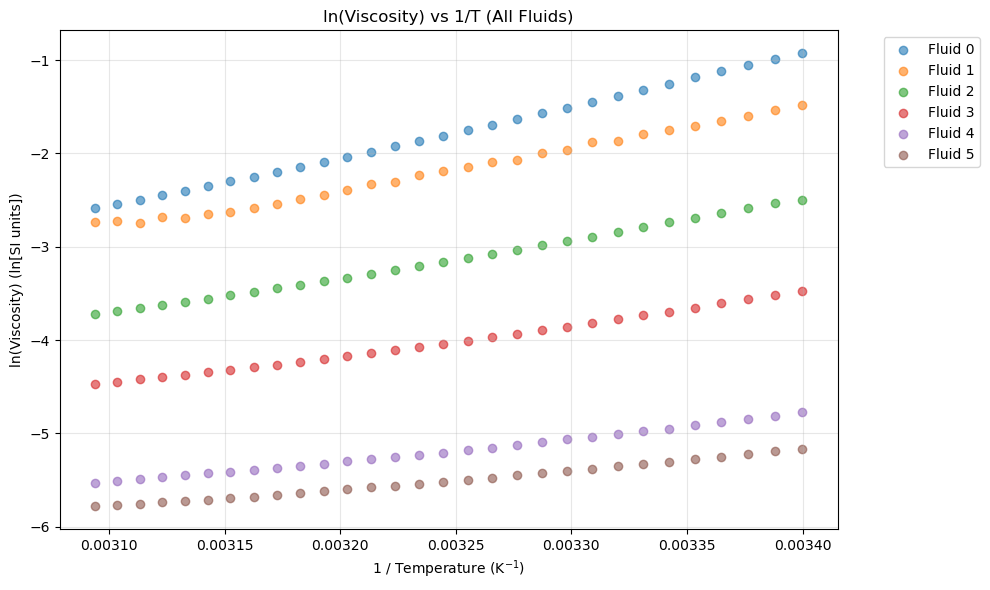

In [9]:

from fairfluids.core.lib import Properties, Parameters
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

viscosity_col = f"prop_{Properties.VISCOSITY.value}"
temp_col = f"param_{Parameters.TEMPERATURE.value}"

plotted_any = False
R = 8.314462618  # J/(mol·K), universal gas constant, not strictly required for just 1/T
for i, fluid in enumerate(docs.fluid):
    df = fluid_to_dataframe(fluid)
    if viscosity_col in df.columns and temp_col in df.columns:
        temperature = df[temp_col]  # assume K
        viscosity = df[viscosity_col]
        # Mask physically meaningful values
        mask = (viscosity > 0) & (temperature > 0)
        if mask.any():
            x = 1.0 / temperature[mask]  # 1/T (K^-1)
            y = np.log(viscosity[mask])  # ln(viscosity)
            ax.scatter(x, y, alpha=0.6, label=f"Fluid {i}")
            plotted_any = True

if plotted_any:
    ax.set_xlabel("1 / Temperature (K$^{-1}$)")
    ax.set_ylabel("ln(Viscosity) (ln[SI units])")
    ax.set_title("ln(Viscosity) vs 1/T (All Fluids)")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    print("No matching viscosity/temperature columns found in any fluid.")
    print("Available columns in first fluid:", fluid_to_dataframe(docs.fluid[0]).columns.tolist())

plt.tight_layout()
plt.show()

## 3) Quick validation of results


In [10]:
for i, d in enumerate(docs):
    print(f"Doc {i}: compounds={len(d.compound)} | fluids={len(d.fluid)}")
    if d.fluid and d.fluid[0].sample and d.fluid[0].sample.measurement:
        print("  first fluid measurements:", len(d.fluid[0].sample.measurement))

# Optional: inspect first measurement quickly
if docs and docs[0].fluid and docs[0].fluid[0].sample.measurement:
    m0 = docs[0].fluid[0].sample.measurement[0]
    print("\nFirst measurement summary")
    print("  method:", m0.method)
    print("  n property values:", len(m0.propertyValue))
    print("  n parameter values:", len(m0.parameterValue))

AttributeError: 'tuple' object has no attribute 'compound'

## 4) Save output JSON documents (optional)


In [ ]:
output_dir = workflows_dir / "outputs_from_spreadsheet"
output_dir.mkdir(parents=True, exist_ok=True)

fio.data_from_spreadsheet(
    spreadsheet_path=str(spreadsheet_path),
    output_dir=str(output_dir),
    fetch_from_pubchem=True,
    units=units,
    uncertainty_units=uncertainty_units,
)

json_files = sorted(output_dir.glob("*.json"))
print(f"Saved {len(json_files)} JSON files to {output_dir}")
for p in json_files[:10]:
    print(" -", p.name)

Found 1 unique compound combinations

Fetching compound information from PubChem for 3 unique compounds...

Fetched data for 3 compounds

  Added compound: water -> Water (CID: 962)
  Added compound: Cholinechloride -> Choline Chloride (CID: 6209)
  Added compound: Glycerol -> Glycerol (CID: 753)
Saved document to: /home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet/water_Cholinechloride_Glycerol.json
Saved 1 JSON files to /home/sga/Code/FAIRFluids/Workflows/outputs_from_spreadsheet
 - water_Cholinechloride_Glycerol.json


## Summary

You now have a working tutorial for the structured FAIRFluids spreadsheet workflow:

1. Generate template with `create_datasheet(...)`
2. Fill spreadsheet (`csv` or `xlsx`)
3. Import with `data_from_spreadsheet(...)`
4. Optionally enrich compounds via PubChem (`pubchemID i` preferred)
5. Validate documents/fluids/measurements and export JSON outputs